In [ ]:
pip install catboost optuna wget -qqq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 27.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.8/226.8 kB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.6 MB/s eta 0:00:00


In [ ]:
# get data
import wget
url = "https://raw.githubusercontent.com/shtrausslearning/Data-Science-Portfolio/main/sbe_internship/data.csv"
wget.download(url, 'data.csv')

'data.csv'

## **The Dataset**

### **load dataset**



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns;sns.set_style('whitegrid')
import plotly.express as px

data = pd.read_csv('data.csv',sep=';')
data['REPORTDATE'] = pd.to_datetime(data['REPORTDATE'],format = "%d.%m.%Y")
data.head()

,REPORTDATE,VALUE
0,2013-12-30,3457625638
1,2013-12-31,3417092149
2,2014-01-01,3417092149
3,2014-01-02,3417092149
4,2014-01-03,3417092149


### **Visualise**

In [ ]:
fig = px.line(data, x='REPORTDATE', y='VALUE', title="Volume ",template='plotly_white',width=800,height=400)
fig.show()

## **Feature Engineering**

### **Feature Engineering I: Time Based Features**

Baseline testing will include only time based features

In [ ]:
data['dow'] = data['REPORTDATE'].dt.dayofweek
data['y']=data['REPORTDATE'].dt.year
data['d']=data['REPORTDATE'].dt.day
data['m']=data['REPORTDATE'].dt.month
data.head()

,REPORTDATE,VALUE,dow,y,d,m
0,2013-12-30,3457625638,0,2013,30,12
1,2013-12-31,3417092149,1,2013,31,12
2,2014-01-01,3417092149,2,2014,1,1
3,2014-01-02,3417092149,3,2014,2,1
4,2014-01-03,3417092149,4,2014,3,1


### **Feature Engineering II: Technical Metrics**

Second feature engineering approach will combine both technical metrics as well as modifications of time series based on statistical testing, so the subset is assebled later

In [ ]:
'''

Technical Indicators & Sample Usage

'''

import numpy as np

#Calculation of moving average
def ma(df,column,n):
    return pd.Series(df[column].rolling(n, min_periods=n).mean(), name='MA_' + str(n))

# exponentially weighted moving average
def ema(df,column,n):
    return pd.Series(df[column].ewm(span=n,min_periods=n).mean(), name='EMA_' + str(n))

#Calculation of price momentum
def mom(df,column,n):
    return pd.Series(df[column].diff(n), name='Momentum_' + str(n))

# rate of change
def roc(df, column, n):
    M = df[column].diff(n - 1) ; N = df[column].shift(n - 1)
    return pd.Series(((M / N) * 100), name = 'ROC_' + str(n))

# relative strength index
def rsi(df, period):
    delta = df.diff().dropna()
    u = delta * 0; d = u.copy()
    u[delta > 0] = delta[delta > 0]; d[delta < 0] = -delta[delta < 0]
    u[u.index[period-1]] = np.mean( u[:period] ) #first value is sum of avg gains
    u = u.drop(u.index[:(period-1)])
    d[d.index[period-1]] = np.mean( d[:period] ) #first value is sum of avg losses
    d = d.drop(d.index[:(period-1)])
    rs = u.ewm(com=period-1, adjust=False).mean() / d.ewm(com=period-1, adjust=False).mean()
    return 100 - 100 / (1 + rs)

# stochastic oscillators slow & fast
def sto(close, low, high, n,id):
    stok = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
    if(id is 0):
        return stok
    else:
        return stok.rolling(3).mean()

# ''' Moving Average '''
# ldf['MA21'] = ma(ldf,10)
# ldf['MA63'] = ma(ldf, 30)
# ldf['MA252'] = ma(ldf, 200)
# lst_MA = ['MA21','MA63','MA252']

# ''' Exponentially Weighted Moving Average '''
# ldf['EMA10'] = ema(ldf, 10)
# ldf['EMA30'] = ema(ldf, 30)
# ldf['EMA200'] = ema(ldf, 200)
# lst_EMA = ['EMA10','EMA30','EMA200']

# ''' Momentum '''
# ldf['MOM10'] = mom(ldf['Close'], 10)
# ldf['MOM30'] = mom(ldf['Close'], 30)
# lst_MOM = ['MOM10','MOM30']

# ''' Relative Strength Index '''
# ldf['RSI10'] = rsi(ldf['Close'], 10)
# ldf['RSI30'] = rsi(ldf['Close'], 30)
# ldf['RSI200'] = rsi(ldf['Close'], 200)
# lst_RSI = ['RSI10','RSI30','RSI200']

# Requires Low/High/Close Values

# ''' Slow Stochastic Oscillators '''
# ldf['%K10'] = sto(ldf['Close'], ldf['Low'], ldf['High'],5,0)
# ldf['%K30'] = sto(ldf['Close'], ldf['Low'], ldf['High'],10,0)
# ldf['%K200'] = sto(ldf['Close'], ldf['Low'], ldf['High'], 20,0)
# lst_pK = ['%K10','%K30','%K200']

# ''' Fast Stochastic Oscillators '''
# ldf['%D10'] = sto(ldf['Close'], ldf['Low'], ldf['High'], 10,1)
# ldf['%D30'] = sto(ldf['Close'], ldf['Low'], ldf['High'], 30,1)
# ldf['%D200'] = sto(ldf['Close'], ldf['Low'], ldf['High'], 200,1)
# lst_pD = ['%D10','%D30','%D200']

<>:41: SyntaxWarning:

"is" with a literal. Did you mean "=="?

<>:41: SyntaxWarning:

"is" with a literal. Did you mean "=="?

<ipython-input-8-70b4382f345a>:41: SyntaxWarning:

"is" with a literal. Did you mean "=="?



## **Exploratory Data Analysis**

### Statistical variations (boxplots) of VALUE by year and month

In [ ]:
px.box(data,x='m',color='y',y='VALUE',template='plotly_white',width=800,height=400,title='Отображения основных статистических характеристик (по месяцам)')

### Mean VALUE by year and month

In [ ]:
px.line(data.groupby(['y','m'],as_index=False).agg('mean'),x='m',color='y',y='VALUE',template='plotly_white',width=800,height=400)

<ipython-input-9-eb4626ffdb07>:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



### Univariate Distribution of VALUE

In [ ]:
px.histogram(data,x='VALUE',height=400,width=800,template='plotly_white',marginal='box')

### Linear Correlation to target variable

In [ ]:
# Plot Correlation to Target Variable only
def corrMat(df,target='demand',figsize=(4,0.5),ret_id=False):

    corr_mat = df.corr().round(2);shape = corr_mat.shape[0]
    corr_mat = corr_mat.transpose()
    corr = corr_mat.loc[:, df.columns == target].transpose().copy()
    return corr

# What are the correlations like
subset = data[['dow','y','d','m','VALUE']]
corrMat(subset,target='VALUE')

,dow,y,d,m,VALUE
VALUE,0.01,0.94,-0.05,0.1,1.0


## **Statistical Testing**

### 1) Checking if two distributions come from the same distribution

The null hypothesis that the distribution underlying sample x is the same as the distribution underlying sample y

In [ ]:
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(data['dow'], data['VALUE'])
print('Mann-Whitney test=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
		print('You cant reject the null hypothesis')
else:
		print('Rejecting the null hypothesis')

Mann-Whitney test=0.000, p=0.000
Rejecting the null hypothesis


In [ ]:
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(data['y'], data['VALUE'])
print('Mann-Whitney test=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
		print('You cant reject the null hypothesis')
else:
		print('Rejecting the null hypothesis')

Mann-Whitney test=0.000, p=0.000
Rejecting the null hypothesis


### 2) Converting time serieis stationarity

Time series stationarity testing & adjustments to remove non stationarity in the data using two statistical metrics (autocorrelation & dickey-fuller)

In [ ]:
'''

Helper function

'''

import statsmodels.tsa.api as smt
import statsmodels.api as sm

def tsplot(y, lags=None, figsize=(8,4), style='bmh'):

    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):

        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Time series analysis')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

        criterion = sm.tsa.stattools.adfuller(y)[1]
        print(f"Dickey-Fuller criterion: p={criterion}")
        plt.tight_layout()
        plt.show()


### (a) Baseline Time Series

Let's use the series as it is

Dickey-Fuller criterion: p=0.934988760701965


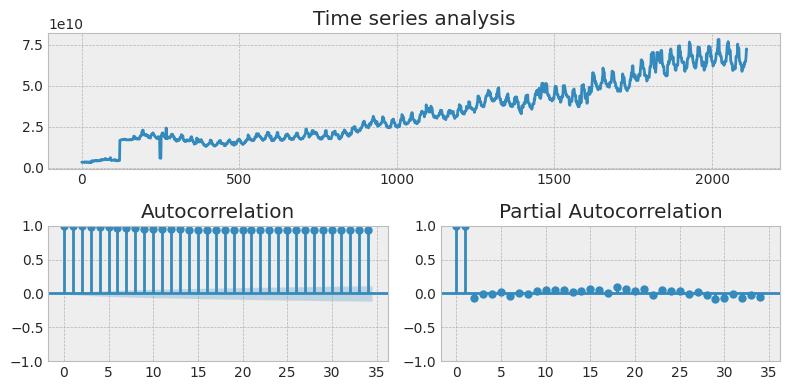

In [ ]:
tsplot(data['VALUE'])

This is a nightmare from the point of view of the stationarity of the series,

 ### (b) Box-cox transformation

 let's try to at least slightly **reduce the statistical criterion** using box-cox transformation

Dickey-Fuller criterion: p=0.33953657978375956


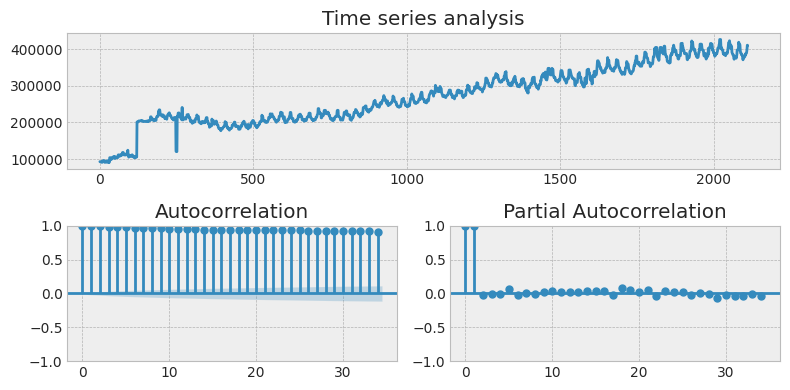

The optimal parameter of the Box-Cox transformation is: 0.488251


In [ ]:
import scipy.stats as scs

data['VALUE_box'], lmbda = scs.boxcox(data['VALUE'])
tsplot(data['VALUE_box'])
print("The optimal parameter of the Box-Cox transformation is: %f" % lmbda)

### (c) Taking into account seasonal differences

Let's take seasonal differences. For a season, we will take a period of **1 month**

Dickey-Fuller criterion: p=1.3329526107395548e-13


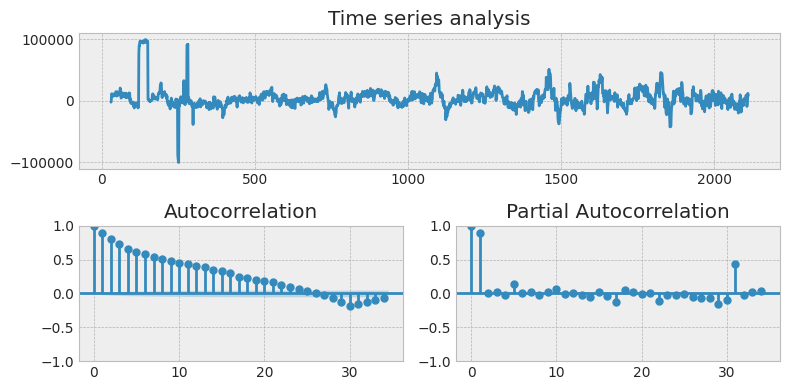

In [ ]:
data['VALUE_box_season'] = data['VALUE_box'] - data['VALUE_box'].shift(30)
tsplot(data.VALUE_box_season[30:])

- The Dickey-Fuller test rejects the null hypothesis of non-stationarity,
- but the plot of autocorrelation and partial autocorrelation tells us that we need to take another unit difference.

### (d) Final Tweaking

Dickey-Fuller criterion: p=6.437091549657279e-20


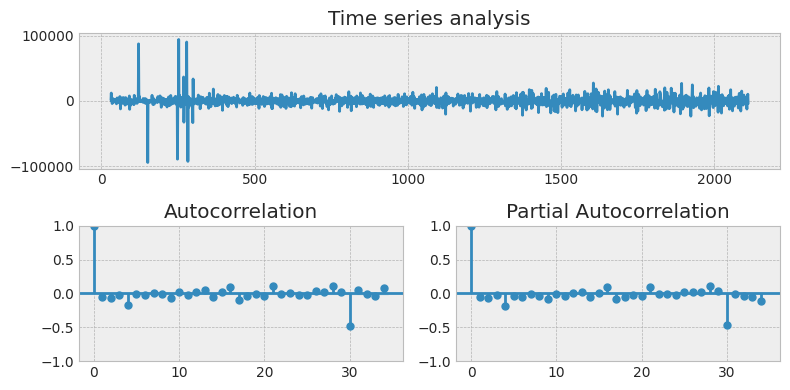

In [ ]:
data['VALUE_box_season_diff'] = data.VALUE_box_season - data['VALUE_box_season'].shift(1)
tsplot(data['VALUE_box_season_diff'][30+1:])

In [ ]:
data.head()

,REPORTDATE,VALUE,dow,y,d,m,VALUE_box,VALUE_box_season,VALUE_box_season_diff
0,2013-12-30,3457625638,0,2013,30,12,93039.660413,NaN,NaN
1,2013-12-31,3417092149,1,2013,31,12,92505.507470,NaN,NaN
2,2014-01-01,3417092149,2,2014,1,1,92505.507470,NaN,NaN
3,2014-01-02,3417092149,3,2014,2,1,92505.507470,NaN,NaN
4,2014-01-03,3417092149,4,2014,3,1,92505.507470,NaN,NaN


## **Training Models**

let's create models for a **three month**, **six month** horizons using several approaches

**Feature engineering approaches** we'll look at
- Time series based feature information (which we extracted from `REPORTDATE`)
- Aggregated modifications of the time series **VALUE**


### (1) Standard models based on time features

CatBoost works quite well out of the box, by selecting hyperparameters based an analysis of the input dataset, so let's make that our baseline

In [ ]:
# Plot Correlation to Target Variable only
def corrMat(df,target='demand',figsize=(4,0.5),ret_id=False):

    corr_mat = df.corr().round(2);shape = corr_mat.shape[0]
    corr_mat = corr_mat.transpose()
    corr = corr_mat.loc[:, df.columns == target].transpose().copy()
    return corr

# What are the correlations like
subset = data[['dow','y','d','m','VALUE']]
corrMat(subset,target='VALUE')

,dow,y,d,m,VALUE
VALUE,0.01,0.94,-0.05,0.1,1.0


In [ ]:
# initial splitting
X = subset[['dow','y','d','m']]
y = subset[['VALUE']]

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

# helper function for plotting in plotly
def prepare_output(model,X_train,y_train,X_test,y_test):

    # predict & merge
    y_pred_tr = pd.Series(model.predict(X_train),y_train.index,name='pred').to_frame()
    y_pred_tr['ground'] = y_train['VALUE']
    y_pred_tr['subset'] = 'train'
    y_pred = model.predict(X_test)
    y_pred_te = pd.Series(y_pred,y_test.index,name='pred').to_frame()
    y_pred_te['ground'] = y_test['VALUE']
    y_pred_te['subset'] = 'test'
    print('test rmse:',f'{mean_squared_error(y_pred,y_test,squared=False):.4e}')

    all = pd.concat([y_pred_tr,y_pred_te],axis=0)
    all['diff'] = abs(all['pred'] - all['ground'])
    return all

# helper function to split the dataset by days
def get_split(n:int):
    X_train = X[:-30*n]
    y_train = y[:-30*n]
    X_test = X[-30*n:]
    y_test = y[-30*n:]
    max_tr = max(list(X_train.index))
    return X_train,y_train,X_test,y_test,max_tr

In [ ]:
# 3 month split for test set
X_train,y_train,X_test,y_test,max_tr = get_split(3)

# train
model = CatBoostRegressor(silent=True)
model.fit(X_train,y_train)

all = prepare_output(model,X_train,y_train,X_test,y_test)
fig = px.line(all,all.index,y=['pred','ground','diff'],template='plotly_white',width=800,height=300,title='3 month forecast model')
fig.update_xaxes(range = [1500,2100])
fig.add_vrect(x0=0, x1=max_tr, line_width=0, fillcolor="yellow", opacity=0.1)
fig.add_vline(x=max_tr)

test rmse: 3.4351e+09


In [ ]:
# 6 month split for test set
X_train,y_train,X_test,y_test,max_tr = get_split(6)

# train
model = CatBoostRegressor(silent=True)
model.fit(X_train,y_train)

all = prepare_output(model,X_train,y_train,X_test,y_test)
fig = px.line(all,all.index,y=['pred','ground','diff'],template='plotly_white',width=800,height=300,title='6 month forecast model')
fig.update_xaxes(range = [1500,2100])
fig.add_vrect(x0=0, x1=max_tr, line_width=0, fillcolor="yellow", opacity=0.1)
fig.add_vline(x=max_tr)

test rmse: 1.6883e+10


### **Optimisation of Hyperparameters**

Instead of utilising a brute force based GridSearch, lets use **optuna** to optimise our hyperparameters. We first need to create an objective function, which should include:
- a hyperparameter set corresponding to the model hyperparameters
- desired model to be optimised
- defined evaluation metric, which needs to be the return value

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# Define objective function for Optuna
def objective(trial):

    # Define hyperparameters to optimize
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10)
    }

    # Initialize CatBoostRegressor with the hyperparameters
    model = CatBoostRegressor(**params, verbose=0)
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)

    return mse

Let's optimise the hyperparameters so the model performs the best in the interval of a **3 month prediction**

In [ ]:
X_train,y_train,X_val,y_val,max_tr = get_split(3)

# Create study object and optimize the objective function
study = optuna.create_study(direction='minimize',)
study.optimize(objective, n_trials=100,show_progress_bar=True)

# Get the best hyperparameters found by Optuna
best_params = study.best_params
print("Best hyperparameters:", best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

Best hyperparameters: {'learning_rate': 0.0529631555445691, 'depth': 4, 'l2_leaf_reg': 2.50312349034641}


In [ ]:
best_model = CatBoostRegressor(**best_params, verbose=0)
best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_val)

all = prepare_output(best_model,X_train,y_train,X_val,y_val)
fig = px.line(all,all.index,y=['pred','ground','diff'],template='plotly_white',width=800,height=300,title='3 month forecast model (optimised hyperparameters)')
fig.update_xaxes(range = [1500,2100])
fig.add_vrect(x0=0, x1=max_tr, line_width=0, fillcolor="yellow", opacity=0.1)
fig.add_vline(x=max_tr)

test rmse: 1.1833e+09


Let's optimise the hyperparameters so the model performs the best in the interval of a **6 month prediction**

In [ ]:
X_train,y_train,X_val,y_val,max_tr = get_split(6)

# Create study object and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100,show_progress_bar=True)

# Get the best hyperparameters found by Optuna
best_params = study.best_params
print("Best hyperparameters:", best_params)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
best_model = CatBoostRegressor(**best_params, verbose=0)
best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_val)

all = prepare_output(best_model,X_train,y_train,X_val,y_val)
fig = px.line(all,all.index,y=['pred','ground','diff'],template='plotly_white',width=800,height=300,title='6 month forecast model (optimised hyperparameters)')
fig.update_xaxes(range = [1500,2100])
fig.add_vrect(x0=0, x1=max_tr, line_width=0, fillcolor="yellow", opacity=0.1)
fig.add_vline(x=max_tr)

### (2) Aggregative based feature

There are a number of aggregative type features we can utilise, unfortunatelly standard **moving** averages and **exponentially weighted** averages features have a very high correlation to the features so I have opted to exclude them, and going for **mom** and **roc** & statistical features instead

In [ ]:
subset = data[['dow','y','d','m','VALUE']]
corrMat(subset,target='VALUE')

data['MOM100'] = mom(data,'VALUE',100)
data['MOM200'] = mom(data,'VALUE',200)
data['MOM300'] = mom(data,'VALUE',300)

data['ROC100'] = roc(data,'VALUE',100)
data['ROC200'] = roc(data,'VALUE',200)
data['ROC300'] = roc(data,'VALUE',300)


In [ ]:
subset = data[['dow','y','d','m','VALUE','MOM100','MOM200','MOM300','VALUE_box_season_diff','VALUE_box_season','ROC100','ROC200','ROC300']]
print(subset.shape)
subset = subset.dropna()
print(subset.shape)
corrMat(subset,target='VALUE')

y = subset[['VALUE']].copy()
X = subset.drop(['VALUE'],axis=1).copy()

In [ ]:
# 6 month split for test set
X_train,y_train,X_test,y_test,max_tr = get_split(6)

# train
model = CatBoostRegressor(silent=True)
model.fit(X_train,y_train)

all = prepare_output(model,X_train,y_train,X_test,y_test)
fig = px.line(all,all.index,y=['pred','ground','diff'],template='plotly_white',width=800,height=300,title='6 month forecast model')
fig.update_xaxes(range = [1500,2100])
fig.add_vrect(x0=0, x1=max_tr, line_width=0, fillcolor="yellow", opacity=0.1)
fig.add_vline(x=max_tr)

In [ ]:
X_train,y_train,X_val,y_val,max_tr = get_split(6)

# Create study object and optimize the objective function
study = optuna.create_study(direction='minimize',)
study.optimize(objective, n_trials=100,show_progress_bar=True)

# Get the best hyperparameters found by Optuna
best_params = study.best_params
print("Best hyperparameters:", best_params)

In [ ]:
best_model = CatBoostRegressor(**best_params, verbose=0)
best_model.fit(X_train,y_train)
y_pred = best_model.predict(X_val)

all = prepare_output(best_model,X_train,y_train,X_val,y_val)
fig = px.line(all,all.index,y=['pred','ground','diff'],template='plotly_white',width=800,height=300,title='6 month forecast model (optimised hyperparameters)')
fig.update_xaxes(range = [1500,2100])
fig.add_vrect(x0=0, x1=max_tr, line_width=0, fillcolor="yellow", opacity=0.1)
fig.add_vline(x=max_tr)

In [ ]:
importances = best_model.get_feature_importance(type='PredictionValuesChange')
feature_importances = pd.Series(importances, index=X.columns,name='fi').sort_values()
px.bar(feature_importances,template='plotly_white',height=300,width=800,title='Feature importance')